In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve,
    auc,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

## Load file

In [2]:
# Load feature matrix and target vector
X_Uncleaned = pd.read_csv("./X.csv")
y_Uncleaned = pd.read_csv("./y.csv")

# Remove index column
X = X_Uncleaned.iloc[:, 1:]
y = y_Uncleaned.iloc[:, 1:]

In [3]:
loadPickleFile = pd.read_pickle("./rf_model.pkl")
# print(loadPickleFile)

### Preprocess X and Y

In [4]:
# Stratify on binary depression status just to keep it balanced
y_binary = np.where(y >= 10, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_binary, random_state=42
)

y_train_binary = np.where(y_train >= 10, 1, 0)
y_test_binary = np.where(y_test >= 10, 1, 0)

### Build Model

In [5]:
# Extract the hyperparams
params_rf = (
    loadPickleFile.get_params()
)  # --> Used to get paramters of a fresh model (not trained yet)

### Checking current status of sample

In [6]:
print("Shape of sample:", X_train.shape)
print("Class distribution:", np.bincount(y_train_binary.ravel()))

Shape of sample: (7202, 33)
Class distribution: [5752 1450]


## Step 2A: Baseline Training 

In [7]:
# Initialize Random Forest Regressor
model_baseline_rf = RandomForestRegressor(
    n_estimators=100, max_depth=None, random_state=42, n_jobs=-1
)
model_baseline_rf.fit(X_train, y_train.values.ravel())

# Predict on test set
y_pred_scores_baseline_rf = model_baseline_rf.predict(X_test)

# Binarize predictions (threshold at PHQ-9 >= 10)
y_pred_binary_baseline_rf = (y_pred_scores_baseline_rf >= 10).astype(int)

In [8]:
# Evaluate baseline Random Forest
metrics_baseline_rf = {
    "accuracy": accuracy_score(y_test_binary, y_pred_binary_baseline_rf),
    "precision": precision_score(y_test_binary, y_pred_binary_baseline_rf),
    "recall": recall_score(y_test_binary, y_pred_binary_baseline_rf),
    "f1": f1_score(y_test_binary, y_pred_binary_baseline_rf),
    "auc": roc_auc_score(y_test_binary, y_pred_scores_baseline_rf),
}

Notes

This ravel() is only needed for scikit-learn models (like Random Forest, Logistic Regression, etc.).

For XGBoost, it was OK to use 2D (n_samples, 1) because XGBoost handles it internally.

## Step 2B: Undersampling

In [9]:
# Count number of 0s and 1s in y_train_binary
counter = Counter(y_train_binary.ravel())
minority_class_count = counter[1]
majority_class_count = counter[0]

print(f"Minority class count: {minority_class_count}")
print(f"Majority class count: {majority_class_count}")

Minority class count: 1450
Majority class count: 5752


In [10]:
# For 1.5:1 (majority = 1.5x minority)
desired_majority_count_1_5 = int(1.5 * minority_class_count)
sampling_strategy_1_5to1 = minority_class_count / desired_majority_count_1_5

print(f"Sampling strategy for 1.5:1:", sampling_strategy_1_5to1)

Sampling strategy for 1.5:1: 0.6666666666666666


In [11]:
# For 2:1 (majority = 2x minority)
desired_majority_count_2 = int(2.0 * minority_class_count)
sampling_strategy_2to1 = minority_class_count / desired_majority_count_2

print(f"Sampling strategy for 2:1:", sampling_strategy_2to1)

Sampling strategy for 2:1: 0.5


### Functions to undersample based on selected ratios

In [12]:
# Function: Perform Random Undersampling on the training data
# Inputs:
#   - X_train: Features for training
#   - y_train: Continuous PHQ-9 scores for training
#   - y_train_binary: Binary 0/1 labels for training (used for sampling)
#   - sampling_ratio: Desired ratio of minority to majority class (e.g., 1.0 for 1:1)
# Outputs:
#   - X_train_under: Features after undersampling
#   - y_train_under_continuous: Continuous PHQ-9 scores corresponding to sampled features
def undersample_data(X_train, y_train, y_train_binary, sampling_ratio):
    undersampler = RandomUnderSampler(sampling_strategy=sampling_ratio, random_state=42)
    X_train_under, y_train_under_binary = undersampler.fit_resample(
        X_train, y_train_binary
    )

    # Match the sampled features with original continuous labels
    selected_indices = undersampler.sample_indices_
    y_train_under_continuous = y_train.iloc[selected_indices].reset_index(drop=True)

    return X_train_under, y_train_under_continuous

In [13]:
from sklearn.ensemble import RandomForestRegressor


# Function: Train Random Forest model and evaluate on test set
# Inputs:
#   - X_train_under: Features after undersampling
#   - y_train_under_continuous: Continuous PHQ-9 scores for training
#   - X_test: Features for testing (original test set)
#   - y_test_binary: Binary 0/1 labels for test set (for evaluation)
#   - params_rf: Hyperparameters for Random Forest model
# Outputs:
#   - y_pred_scores: Predicted continuous PHQ-9 scores on test set
#   - y_pred_binary: Binarized predictions (0/1) based on threshold PHQ-9 ≥ 10
#   - metrics: Dictionary of evaluation metrics (accuracy, precision, recall, f1, auc)
def train_and_evaluate_random_forest(
    X_train_under, y_train_under_continuous, X_test, y_test_binary, params_rf
):
    model = RandomForestRegressor(**params_rf)
    model.fit(X_train_under, y_train_under_continuous)

    y_pred_scores = model.predict(X_test)
    y_pred_binary = (y_pred_scores >= 10).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test_binary, y_pred_binary),
        "precision": precision_score(y_test_binary, y_pred_binary),
        "recall": recall_score(y_test_binary, y_pred_binary),
        "f1": f1_score(y_test_binary, y_pred_binary),
        "auc": roc_auc_score(y_test_binary, y_pred_scores),
    }

    return y_pred_scores, y_pred_binary, metrics

### 1:1 Random Undersampling

In [14]:
# 1:1 Undersample and train RF
X_train_under_1to1, y_train_under_continuous_1to1 = undersample_data(
    X_train, y_train, y_train_binary, sampling_ratio=1.0
)

y_pred_scores_1to1_rf, y_pred_binary_1to1_rf, metrics_1to1_rf = (
    train_and_evaluate_random_forest(
        X_train_under_1to1,
        y_train_under_continuous_1to1,
        X_test,
        y_test_binary,
        params_rf,
    )
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### 1.5:1 Ratio (Moderate Undersampling)

In [15]:
# 1.5:1 Undersample
X_train_under_1_5to1, y_train_under_continuous_1_5to1 = undersample_data(
    X_train, y_train, y_train_binary, sampling_ratio=sampling_strategy_1_5to1
)

# Train and evaluate on 1.5:1 undersampled data
y_pred_scores_1_5to1_rf, y_pred_binary_1_5to1_rf, metrics_1_5to1_rf = (
    train_and_evaluate_random_forest(
        X_train_under_1_5to1,
        y_train_under_continuous_1_5to1,
        X_test,
        y_test_binary,
        params_rf,
    )
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### 2:1 Ratio (Light Undersampling)

In [16]:
# 2:1 Undersample
X_train_under_2to1, y_train_under_continuous_2to1 = undersample_data(
    X_train, y_train, y_train_binary, sampling_ratio=sampling_strategy_2to1
)

# Train and evaluate on 2:1 undersampled data
y_pred_scores_2to1_rf, y_pred_binary_2to1_rf, metrics_2to1_rf = (
    train_and_evaluate_random_forest(
        X_train_under_2to1,
        y_train_under_continuous_2to1,
        X_test,
        y_test_binary,
        params_rf,
    )
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


## Step 2C: Oversampling with SMOTE

In [17]:
# Function: Perform SMOTE oversampling (already defined)
def oversample_data(X_train, y_train, y_train_binary):
    oversampler = SMOTE(sampling_strategy=1.0, random_state=42)
    X_train_over, y_train_over_binary = oversampler.fit_resample(
        X_train, y_train_binary
    )

    # Minor fix: Because SMOTE creates synthetic samples, match labels by sampling minority scores
    minority_indices = np.where(y_train_binary.ravel() == 1)[0]
    y_train_minority = y_train.iloc[minority_indices].reset_index(drop=True)

    n_minority_original = sum(y_train_binary.ravel() == 1)
    n_minority_synthetic = X_train_over.shape[0] - X_train.shape[0]

    y_train_over_continuous = pd.concat(
        [
            y_train.reset_index(drop=True),
            y_train_minority.sample(
                n=n_minority_synthetic, replace=True, random_state=42
            ),
        ]
    ).reset_index(drop=True)

    return X_train_over, y_train_over_continuous

In [18]:
# Step 1: Oversample
X_train_over, y_train_over_continuous = oversample_data(
    X_train, y_train, y_train_binary
)

# Step 2: Train and evaluate on SMOTE oversampled data
y_pred_scores_over_rf, y_pred_binary_over_rf, metrics_over_rf = (
    train_and_evaluate_random_forest(
        X_train_over, y_train_over_continuous, X_test, y_test_binary, params_rf
    )
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### Print all results

In [19]:
# Create updated dictionary including baseline for Random Forest
metrics_dict_rf = {
    "Baseline (No Resampling)": metrics_baseline_rf,
    "1:1 Undersample": metrics_1to1_rf,
    "1.5:1 Undersample": metrics_1_5to1_rf,
    "2:1 Undersample": metrics_2to1_rf,
    "SMOTE Oversample": metrics_over_rf,
}

# Convert to DataFrame
metrics_table_rf = pd.DataFrame(metrics_dict_rf).T
metrics_table_rf = metrics_table_rf[["accuracy", "precision", "recall", "f1", "auc"]]

# Show the table
print(metrics_table_rf)

                          accuracy  precision    recall        f1       auc
Baseline (No Resampling)  0.923931   0.854890  0.748619  0.798233  0.975868
1:1 Undersample           0.951694   0.806236  1.000000  0.892725  0.992010
1.5:1 Undersample         0.951694   0.806236  1.000000  0.892725  0.991722
2:1 Undersample           0.948362   1.000000  0.743094  0.852615  0.991824
SMOTE Oversample          0.924486   0.726908  1.000000  0.841860  0.991318


In [20]:
# For Random Forest metrics (assuming you have a similar DataFrame)
metrics_table_rf.to_csv("random_forest_metrics.csv", index=True)

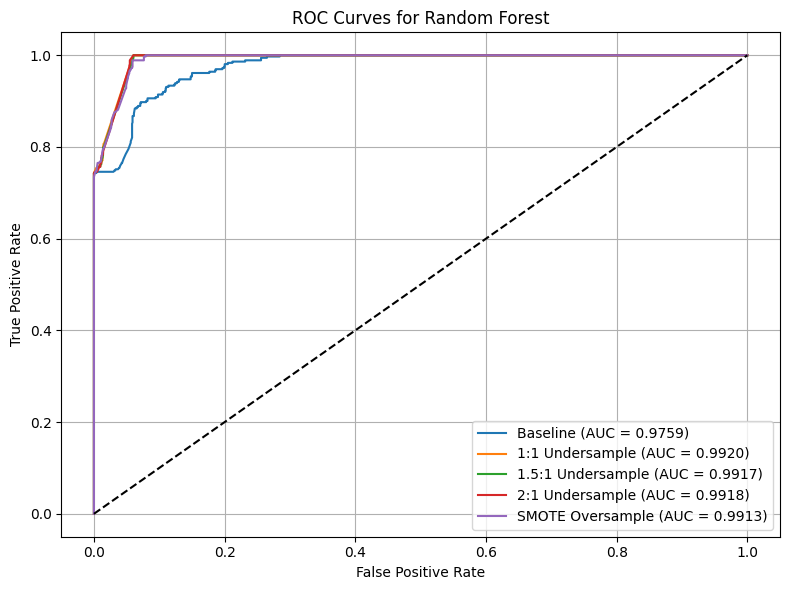

In [21]:
# Calculate ROC curves
fpr_baseline_rf, tpr_baseline_rf, _ = roc_curve(
    y_test_binary, y_pred_scores_baseline_rf
)
fpr_1to1_rf, tpr_1to1_rf, _ = roc_curve(y_test_binary, y_pred_scores_1to1_rf)
fpr_1_5to1_rf, tpr_1_5to1_rf, _ = roc_curve(y_test_binary, y_pred_scores_1_5to1_rf)
fpr_2to1_rf, tpr_2to1_rf, _ = roc_curve(y_test_binary, y_pred_scores_2to1_rf)
fpr_over_rf, tpr_over_rf, _ = roc_curve(y_test_binary, y_pred_scores_over_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline_rf,
    tpr_baseline_rf,
    label="Baseline (AUC = {:.4f})".format(metrics_baseline_rf["auc"]),
)


plt.plot(
    fpr_1to1_rf,
    tpr_1to1_rf,
    label="1:1 Undersample (AUC = {:.4f})".format(metrics_1to1_rf["auc"]),
)
plt.plot(
    fpr_1_5to1_rf,
    tpr_1_5to1_rf,
    label="1.5:1 Undersample (AUC = {:.4f})".format(metrics_1_5to1_rf["auc"]),
)
plt.plot(
    fpr_2to1_rf,
    tpr_2to1_rf,
    label="2:1 Undersample (AUC = {:.4f})".format(metrics_2to1_rf["auc"]),
)
plt.plot(
    fpr_over_rf,
    tpr_over_rf,
    label="SMOTE Oversample (AUC = {:.4f})".format(metrics_over_rf["auc"]),
)

# Chance line
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Random Forest")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()